<a href="https://colab.research.google.com/github/hig3r/colab-probstat/blob/main/%E9%80%A3%E7%B6%9A%E5%9E%8B%E7%A2%BA%E7%8E%87%E5%A4%89%E6%95%B0_%E6%AD%A3%E8%A6%8F%E5%88%86%E5%B8%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 準備



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

In [ ]:
np.random.seed(1637)

## 連続型確率変数

scipy.stats で確率密度関数を自由に与えて, 連続型確率変数を扱うのは少したいへん(自分でクラスを継承して定義する必要がある).

代わりに, 多くの有名な連続型確率変数があらかじめ定義されているので, その固有名詞を探し, 母数(パラメタ)を与えて利用する.

例:指数分布 expon, 一様分布 uniform , 正規分布 norm , カイ二乗分布 chi2 , t分布 t, …



# 標準正規分布 N$(0,1^2)$

パラメタ （母平均値) $\mu=0$, (母分散) $\sigma^2=1^2$ の正規分布$\mathrm{N}(0,1^2)$の確率密度関数

$$ \phi(z)=f(z;0,1^2)=\frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}}.$$


In [ ]:
rvz = stats.norm(loc=0,scale=1) # loc=b=0,   scale=a=1

## 確率密度関数 $\phi(z)$ の計算

In [ ]:
rvz.pdf(1) # f(1) pdf=probability density function

np.float64(0.24197072451914337)

## 累積分布関数 $\Phi(d)=P(Z\leq d)$ の計算 教科書 久保川 数値表(p.290) 公式5.9(p.111)
e-07は$\times10^{-7}$ のこと. float の指数表示 printf("%e",p) でも同じ出力になるでしょ．

In [ ]:
rvz.cdf(3) # P(Z<=3)  cdf=cumulative distribution function

np.float64(0.9986501019683699)

In [ ]:
rvz.cdf(-5)

np.float64(2.866515718791933e-07)

## 確率の計算
 $ P(c \lt Z \leq d)=\Phi(d)-\Phi(c)$

In [ ]:
rvz.cdf(3)-rvz.cdf(1)  # P(1<Z<=3)

np.float64(0.15730535589982697)

In [ ]:
z=0.2
rvz.cdf(z)-rvz.cdf(0)

np.float64(0.07925970943910299)

## 分位数 $\Phi^{-1}(q)$ の計算

In [ ]:
q=0.975
rvz.ppf(q) #percent point function

np.float64(1.959963984540054)

## 分位点 $z_p=\Phi^{-1}(1-p)$ の計算 教科書 久保川 公式5.9(p.111)

In [ ]:
p=0.025
rvz.ppf(1-p)

np.float64(1.959963984540054)

# 一般の正規分布 $\mathrm{N}(\mu,\sigma^2)$

パラメタ （母平均値) $\mu$, (母分散) $\sigma^2$ の正規分布N($\mu$,$\sigma^2$)の確率密度関数

$$ f(x;\mu,\sigma^2)=\frac{1}{\sqrt{2\pi\cdot \sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}.$$


$\mathrm{N}(3,2^2)$

In [ ]:
rvx = stats.norm(loc=3,scale=2) # loc=b=μ=3,   scale=a=σ=2

## $X$ の母平均値・母分散・母標準偏差

In [ ]:
rvx.mean() # 母平均値 mean

np.float64(3.0)

In [ ]:
rvx.var() # 母分散 variance

np.float64(4.0)

In [ ]:
rvx.std() # 母標準偏差 standard deviation

np.float64(2.0)

## $X$ の母期待値・モーメント

In [ ]:
rvx.moment(4) # 3次のモーメント E[X^3]

np.float64(344.99999999999994)

In [ ]:
rvx.expect(lambda x: x**2+5*x+3) # 母期待値 E[X^2+5X+3]

np.float64(31.000000000000007)

## 標準正規分布$Z$と一般の正規分布$X$の確率密度関数と累積分布関数のグラフ

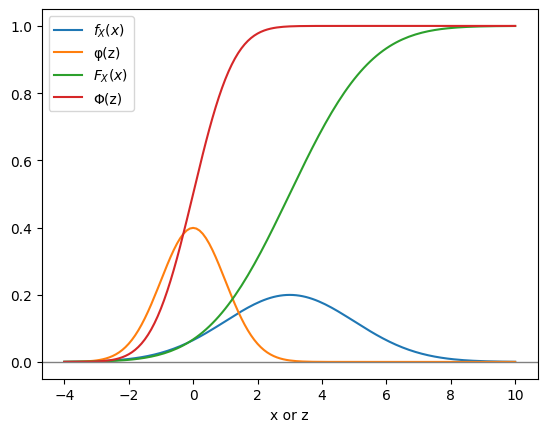

In [ ]:
x=np.linspace(-4,10,141) # 点を打つ x の選択
fig, ax = plt.subplots(1, 1)
ax.plot(x,rvx.pdf(x))
ax.plot(x,rvz.pdf(x))
ax.plot(x,rvx.cdf(x))
ax.plot(x,rvz.cdf(x))
ax.set_xlabel("x or z")
ax.legend(["$f_X(x)$","φ(z)", "$F_X(x)$","Φ(z)"])
ax.axhline(y=0, color='gray', linewidth=1)
fig.show()

## 正規分布 N($3,2^2$)と標準正規分布N($0$,$1^2$)の確率

$P(1 \lt X \leq 4)=P(\frac{1-3}{2} \lt Z \leq \frac{4-3}{2})=\Phi(\frac{4-3}{2})-\Phi(\frac{1-3}{2})$

In [ ]:
rvx.cdf(4)-rvx.cdf(1)

np.float64(0.532807207342556)

In [ ]:
rvz.cdf((4-3)/2)-rvz.cdf((1-3)/2)

np.float64(0.532807207342556)

# 標本ナントカ

### 標本抽出

In [ ]:
n=30
samplez=rvz.rvs(size=n)  # rvs=random variable sample
samplex=rvx.rvs(size=n)  # rvs=random variable sample
[samplez,samplex]

[array([-1.74721197, -1.16158271, -0.33600967,  0.3942817 , -0.662396  ,
        -0.4127101 ,  0.15211487, -0.7130126 ,  1.78051816, -0.67057134,
         0.20086754,  0.24486688, -0.2211888 ,  1.51277797,  0.88721698,
        -0.62888262,  0.13314183,  0.27205976, -0.29848393, -2.32433014,
         0.1664319 ,  0.47243115,  2.38378757,  1.22427331,  0.16688423,
        -1.16131752,  1.13964189, -0.48349256, -0.20309258, -0.70086054]),
 array([ 5.20811822,  3.03942802,  2.74849582,  4.70563195,  7.09354803,
         4.43561998,  4.06611139,  0.39256376,  3.53081619, -0.13458243,
        -0.78242903,  3.0567702 ,  4.56152842,  1.73477035,  3.03210688,
         2.00196792, -0.51939345,  1.90578709,  2.24551547,  6.08386086,
         5.41453005,  3.48255526,  0.07263683,  2.87009586,  1.74876942,
         6.99755853,  0.64275785,  6.84412107,  1.91822026,  3.10987165])]

In [ ]:
[samplex.mean(),samplex.var(),samplex.std()]

[np.float64(3.050245081030805),
 np.float64(4.711846250905651),
 np.float64(2.170678753502151)]

### ヒストグラム

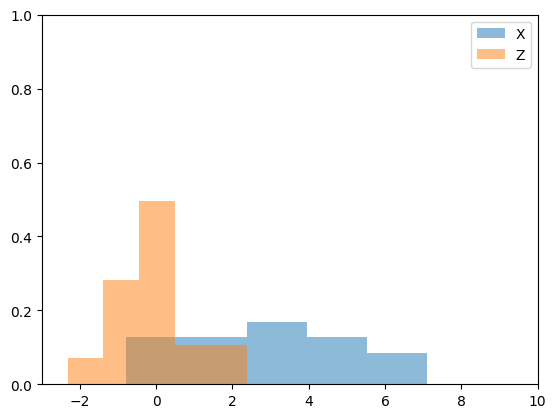

In [ ]:
# ヒストグラム
fig,ax = plt.subplots()
ax.hist(samplex,bins=5,density=True,alpha=0.5)
ax.hist(samplez,bins=5,density=True,alpha=0.5)
ax.set_ylim(0,1)
ax.set_xlim(-3,10)
ax.legend(["X","Z"])
fig.show()

# バックアップ

### 教科書 岩佐 付表1上 $P(0 \lt Z \leq z)$
$P(0 \lt Z \leq z)=\Phi(z)-\frac12$

### 教科書 岩佐 付表1下 $z(\alpha)$ s.t. $P(Z\geq z(\alpha))=\alpha$.
$z(\alpha)=\Phi^{-1}(1-\alpha)$.